In [64]:
import math
import re
from pathlib import Path
from pickle import load

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

mpl.rcParams.update({
    # Use LaTeX
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # Font sizes
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 16,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,

    # Lines
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Axes
    "axes.linewidth": 1,

    # Ticks
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    # Save figures
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

sns.set_palette('tab10')

In [65]:
ROOT = Path.cwd()
if not (ROOT / 'data' / 'single_dot_error.pickle').exists() and (ROOT / 'charge_stability' / 'data' / 'single_dot_error.pickle').exists():
    ROOT = ROOT / 'charge_stability'

DATA_PATH = ROOT / 'data'
FIGURE_PATH = ROOT / 'Figures'
FIGURE_PATH.mkdir(exist_ok=True)

RESULTS_FILE = DATA_PATH / 'single_dot_error.pickle'
with RESULTS_FILE.open('rb') as f:
    single_dot_error_results = load(f)

metadata = single_dot_error_results['metadata']

# Single Dot Time And Memory Analysis

In [66]:
def profile_stage_info(stage_name):
    iteration = None

    match = re.search(r'for iteration (\d+)$', stage_name)
    if match is None:
        iterative_prefixes = (
            'Integrals ',
            'FCI ',
            'Orbital Refinement ',
            'Two-body integrals transformation ',
            'RDM2 transformation ',
        )
        if stage_name.startswith(iterative_prefixes):
            match = re.search(r'(\d+)$', stage_name)

    if match is not None:
        iteration = int(match.group(1))

    if stage_name == 'MAD world initialization':
        stage = 'MAD world initialization'
    elif stage_name in {'MRA potential creation', 'MRA function factory initialization'}:
        stage = 'MRA potential creation'
    elif stage_name == 'Single-particle orbitals calculation':
        stage = 'Single-particle orbitals'
    elif stage_name == 'Integral computation':
        stage = 'Initial integral setup'
    elif stage_name == 'Two-body integrals computation':
        stage = 'Two-body integral setup'
    elif stage_name.startswith('Integrals computation for iteration') or stage_name.startswith('Integrals '):
        stage = 'SCF integrals'
    elif stage_name.startswith('FCI calculation for iteration') or stage_name.startswith('FCI '):
        stage = 'FCI'
    elif stage_name.startswith('Two-body integrals transformation'):
        stage = 'Two-body transform'
    elif stage_name.startswith('RDM2 transformation'):
        stage = 'RDM2 transform'
    elif stage_name.startswith('Orbital Refinement for iteration') or stage_name.startswith('Orbital Refinement '):
        stage = 'Orbital refinement'
    else:
        stage = stage_name

    phase = 'SCF iteration' if iteration is not None else 'Setup'
    return stage, iteration, phase


records = []
profile_records = []

for run in single_dot_error_results['runs']:
    n_electrons = run['n_electrons']
    run_voltage = run.get('V')

    for point in run['points']:
        row = {key: value for key, value in point.items() if key != 'profiler'}
        row['N'] = n_electrons
        row['v'] = run_voltage if run_voltage is not None else point.get('v')
        records.append(row)

        for raw_stage, metrics in point['profiler'].items():
            stage, iteration, phase = profile_stage_info(raw_stage)
            profile_records.append({
                'N': n_electrons,
                'v': row['v'],
                'n_orbitals': point['n_orbitals'],
                'iteration': iteration,
                'iteration_number': None if iteration is None else iteration + 1,
                'phase': phase,
                'stage': stage,
                'raw_stage': raw_stage,
                'time_s': metrics['time_s'],
                'memory_before_MB': metrics['memory_before_MB'],
                'memory_after_MB': metrics['memory_after_MB'],
                'memory_change_MB': metrics['memory_change_MB'],
            })

results_df = (
    pd.DataFrame(records)
    .sort_values(['N', 'n_orbitals'])
    .reset_index(drop=True)
)

profile_df = pd.DataFrame(profile_records)
iteration_profile_df = (
    profile_df[profile_df['iteration'].notna()]
    .assign(
        iteration=lambda df: df['iteration'].astype(int),
        iteration_number=lambda df: df['iteration_number'].astype(int),
    )
    .reset_index(drop=True)
)

stage_order = [
    'SCF integrals',
    'Two-body transform',
    'FCI',
    'RDM2 transform',
    'Orbital refinement',
]
stage_order = [stage for stage in stage_order if stage in iteration_profile_df['stage'].unique()]
stage_colors = dict(zip(stage_order, sns.color_palette('tab10', n_colors=len(stage_order))))

iteration_totals = (
    iteration_profile_df
    .groupby(['N', 'v', 'n_orbitals', 'iteration_number'], as_index=False)
    .agg(
        iteration_time_s=('time_s', 'sum'),
        iteration_memory_change_MB=('memory_change_MB', 'sum'),
    )
)


In [67]:
def summarize_metric_by_stage(metric):
    stats = (
        iteration_profile_df
        .groupby(['N', 'v', 'n_orbitals', 'stage'], as_index=False)
        .agg(
            n_iteration_samples=(metric, 'count'),
            total=(metric, 'sum'),
            mean=(metric, 'mean'),
            median=(metric, 'median'),
            std=(metric, 'std'),
            min=(metric, 'min'),
            q25=(metric, lambda values: values.quantile(0.25)),
            q75=(metric, lambda values: values.quantile(0.75)),
            max=(metric, 'max'),
        )
    )
    stats['std'] = stats['std'].fillna(0.0)
    stats['iqr'] = stats['q75'] - stats['q25']
    return stats


time_stage_stats = summarize_metric_by_stage('time_s')
memory_stage_stats = summarize_metric_by_stage('memory_change_MB')


## Per-Electron Iteration Plots

In [68]:
def electron_title(n_electrons, data):
    v_values = sorted(data['v'].dropna().unique())
    title = f'$N={int(n_electrons)}$ electrons'
    if len(v_values) == 1:
        title += f', $v={v_values[0]:.2f}$ V'
    return title


def save_current_figure(fig, stem):
    fig.savefig(FIGURE_PATH / f'{stem}.pdf', dpi=600)
    fig.savefig(FIGURE_PATH / f'{stem}.png', dpi=300)



def plot_stage_boxplots(metric, ylabel, file_tag, log_y=False):
    for n_electrons in sorted(iteration_profile_df['N'].unique()):
        data_n = iteration_profile_df[iteration_profile_df['N'] == n_electrons]
        stages = [stage for stage in stage_order if stage in data_n['stage'].unique()]

        n_orbitals_count = data_n['n_orbitals'].nunique()
        fig_width = max(9, 0.62 * n_orbitals_count + 3.0)
        fig, ax = plt.subplots(figsize=(fig_width, 5.5))

        sns.boxplot(
            data=data_n,
            x='n_orbitals',
            y=metric,
            hue='stage',
            hue_order=stages,
            palette=stage_colors,
            showfliers=False,
            linewidth=1.0,
            ax=ax,
        )

        ax.set_title(electron_title(n_electrons, data_n))
        ax.set_xlabel('Number of orbitals $M$')
        ax.set_ylabel(ylabel)
        ax.grid(True, which='both', axis='y', alpha=0.25)
        if log_y:
            positive = data_n.loc[data_n[metric] > 0, metric]
            if len(positive) > 0:
                ax.set_yscale('log')
                ax.set_ylim(bottom=positive.min() * 0.8)
        else:
            ax.axhline(0, color='black', linewidth=0.8, alpha=0.35)

        ax.legend(
            title='Stage',
            frameon=False,
            loc='center left',
            bbox_to_anchor=(1.01, 0.5),
        )
        fig.tight_layout()
        save_current_figure(fig, f'single_dot_N{int(n_electrons)}_{file_tag}_stage_boxplot')
        plt.show()

def plot_stage_median_std(stats_df, ylabel, file_tag, log_y=False):
    for n_electrons in sorted(stats_df['N'].unique()):
        data_n = stats_df[stats_df['N'] == n_electrons]
        stages = [stage for stage in stage_order if stage in data_n['stage'].unique()]

        fig, ax = plt.subplots(figsize=(8, 5.5))
        for stage in stages:
            stage_data = data_n[data_n['stage'] == stage].sort_values('n_orbitals')
            x = stage_data['n_orbitals'].to_numpy()
            y = stage_data['median'].to_numpy()
            yerr = stage_data['std'].to_numpy()

            if log_y:
                positive = y[y > 0]
                floor = positive.min() * 0.1 if len(positive) else 1e-12
                lower = np.minimum(yerr, np.maximum(y - floor, 0.0))
                yerr = np.vstack([lower, yerr])

            ax.errorbar(
                x,
                y,
                yerr=yerr,
                marker='o',
                capsize=3,
                color=stage_colors[stage],
                label=stage,
            )

        ax.set_title(electron_title(n_electrons, data_n))
        ax.set_xlabel('Number of orbitals $M$')
        ax.set_ylabel(ylabel)
        ax.grid(True, which='both', axis='y', alpha=0.25)
        if log_y:
            ax.set_yscale('log')
        else:
            ax.axhline(0, color='black', linewidth=0.8, alpha=0.35)
        ax.legend(frameon=False)
        fig.tight_layout()
        save_current_figure(fig, f'single_dot_N{int(n_electrons)}_{file_tag}_stage_median_std')
        plt.show()


def plot_iteration_heatmaps(metric, ylabel, file_tag, cmap, center=None):
    for n_electrons in sorted(iteration_totals['N'].unique()):
        data_n = iteration_totals[iteration_totals['N'] == n_electrons]
        heatmap_data = (
            data_n
            .pivot_table(
                index='n_orbitals',
                columns='iteration_number',
                values=metric,
                aggfunc='sum',
            )
            .sort_index()
        )

        width = max(7, 0.55 * len(heatmap_data.columns))
        height = max(5, 0.33 * len(heatmap_data.index))
        fig, ax = plt.subplots(figsize=(width, height))
        sns.heatmap(
            heatmap_data,
            cmap=cmap,
            center=center,
            mask=heatmap_data.isna(),
            cbar_kws={'label': ylabel},
            ax=ax,
        )
        ax.invert_yaxis()
        ax.set_title(electron_title(n_electrons, data_n))
        ax.set_xlabel('SCF iteration number')
        ax.set_ylabel('Number of orbitals $M$')
        fig.tight_layout()
        save_current_figure(fig, f'single_dot_N{int(n_electrons)}_{file_tag}_iteration_heatmap')
        plt.show()

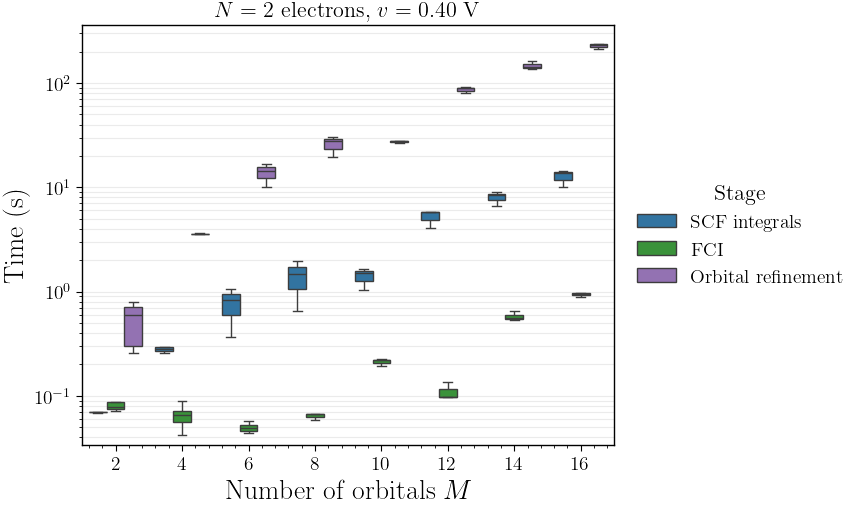

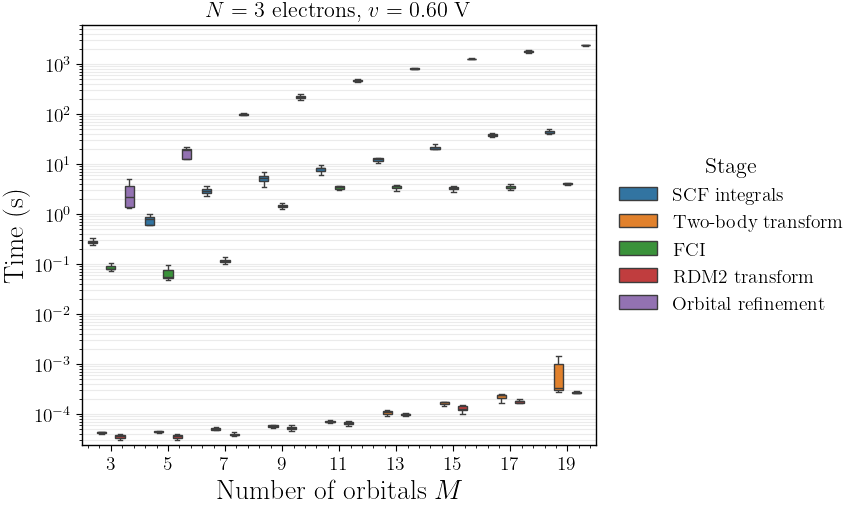

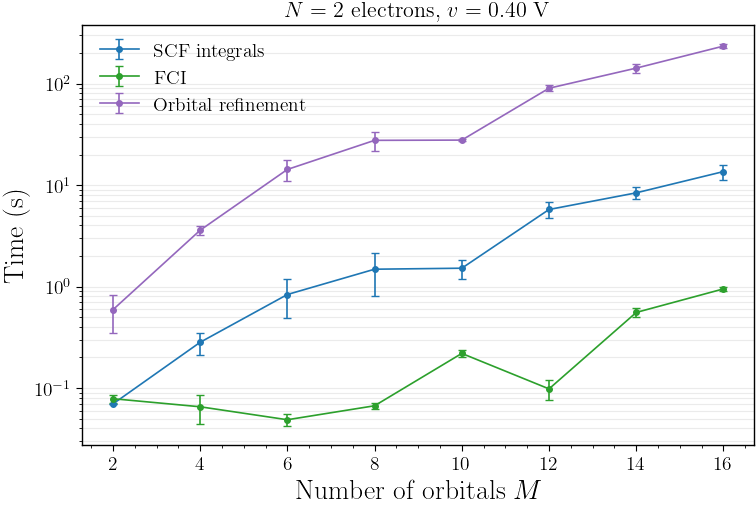

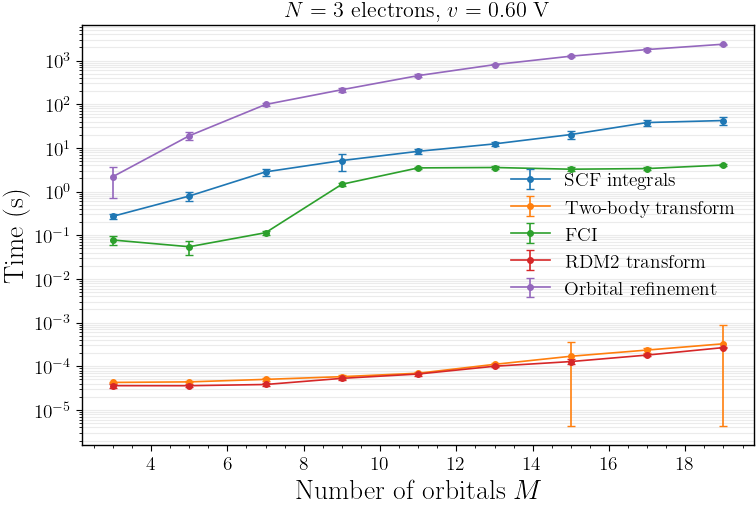

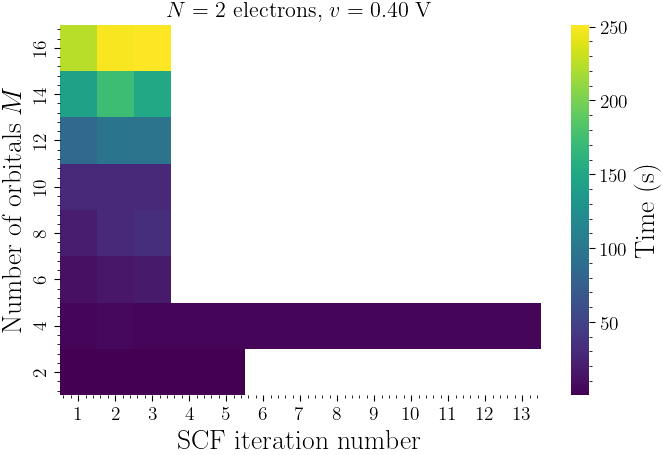

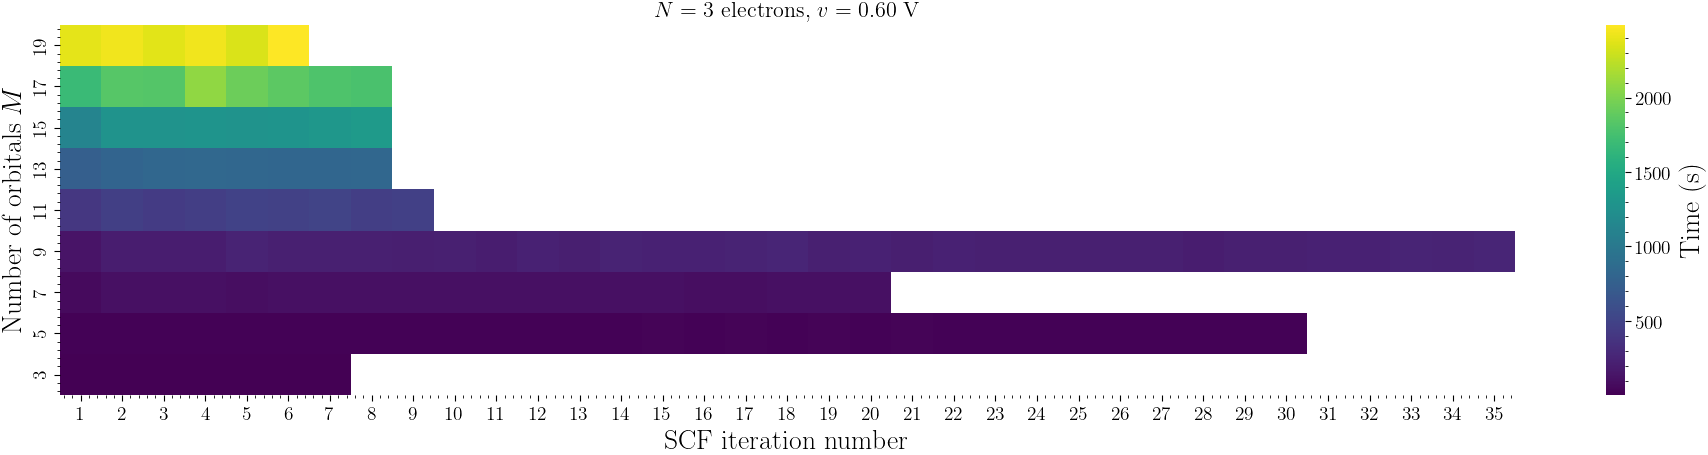

In [69]:
plot_stage_boxplots(
    metric='time_s',
    ylabel='Time (s)',
    file_tag='time',
    log_y=True,
)

plot_stage_median_std(
    stats_df=time_stage_stats,
    ylabel='Time (s)',
    file_tag='time',
    log_y=True,
)

plot_iteration_heatmaps(
    metric='iteration_time_s',
    ylabel='Time (s)',
    file_tag='time',
    cmap='viridis',
)

## Per-Electron Memory Plots

In [ ]:
plot_stage_boxplots(
    metric='memory_change_MB',
    ylabel='Memory change (MB)',
    file_tag='memory',
    log_y=False,
)

plot_stage_median_std(
    stats_df=memory_stage_stats,
    ylabel='Memory change (MB)',
    file_tag='memory',
    log_y=False,
)

plot_iteration_heatmaps(
    metric='iteration_memory_change_MB',
    ylabel='Memory change (MB)',
    file_tag='memory',
    cmap='coolwarm',
    center=0,
)

## Total Time Across Electron Numbers

In [ ]:
profile_total_time = (
    profile_df
    .groupby(['N', 'v', 'n_orbitals'], as_index=False)
    .agg(total_profiled_time_s=('time_s', 'sum'))
)

stage_total_time = (
    iteration_profile_df[iteration_profile_df['stage'].isin(['FCI', 'Orbital refinement'])]
    .groupby(['N', 'v', 'n_orbitals', 'stage'], as_index=False)
    .agg(time_s=('time_s', 'sum'))
    .pivot_table(
        index=['N', 'v', 'n_orbitals'],
        columns='stage',
        values='time_s',
        fill_value=0.0,
    )
    .reset_index()
    .rename(columns={
        'FCI': 'total_fci_time_s',
        'Orbital refinement': 'total_orbital_refinement_time_s',
    })
)
combination_time_totals = (
    profile_total_time
    .merge(stage_total_time, on=['N', 'v', 'n_orbitals'], how='left')
    .fillna({
        'total_fci_time_s': 0.0,
        'total_orbital_refinement_time_s': 0.0,
    })
    .sort_values(['N', 'v', 'n_orbitals'])
)

line_styles = {
    'total_profiled_time_s': ('-', 'Total time'),
    'total_fci_time_s': ('--', 'Total FCI time'),
    'total_orbital_refinement_time_s': (':', 'Total orbital refinement time'),
}

series_keys = list(combination_time_totals[['N', 'v']].drop_duplicates().itertuples(index=False, name=None))
series_colors = dict(zip(series_keys, sns.color_palette('tab10', n_colors=len(series_keys))))

fig, ax = plt.subplots(figsize=(9, 6))
for key in series_keys:
    n_electrons, voltage = key
    data_nv = combination_time_totals[
        (combination_time_totals['N'] == n_electrons) &
        (combination_time_totals['v'] == voltage)
    ]

    for column, (line_style, label) in line_styles.items():
        ax.plot(
            data_nv['n_orbitals'],
            data_nv[column],
            linestyle=line_style,
            marker='o',
            color=series_colors[key],
        )

ax.set_xlabel('Number of orbitals $M$')
ax.set_ylabel('Total profiled time (s)')
ax.set_yscale('log')
ax.grid(True, which='both', axis='y', alpha=0.25)

series_handles = [
    Line2D([0], [0], color=series_colors[key], lw=2, label=f'$N={int(key[0])}$, $v={key[1]:.2f}$ V')
    for key in series_keys
]
style_handles = [
    Line2D([0], [0], color='black', lw=2, linestyle=line_style, label=label)
    for line_style, label in line_styles.values()
]

series_legend = ax.legend(handles=series_handles, title='Parameters', loc='upper left', frameon=False)
ax.add_artist(series_legend)
ax.legend(handles=style_handles, title='Component', loc='lower right', frameon=False)

fig.tight_layout()
save_current_figure(fig, 'single_dot_total_time_components')
plt.show()
